# MINIST Dataset using Sequential method gained 99. Accuracy 

## 1. Introduction
This kernel is your start in Keras & Tensorflow.

MNIST ("Modified National Institute of Standards and Technology") is the de facto “hello world” dataset of computer vision. Since its release in 1999, this classic dataset of handwritten images has served as the basis for benchmarking classification algorithms. A new machine learning techniques emerge, MNIST remains a reliable resource for researchers and learners alike. In this competition, your goal is to correctly identify digits from a dataset of tens of thousands of handwritten images. We’ve curated a set of tutorial-style kernels which cover everything from regression to neural networks. We encourage you to experiment with different algorithms to learn first-hand what works well and how techniques compare.

## 2. Importing Library

In [1]:
from keras.datasets import mnist
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from keras.utils import np_utils
from matplotlib import pyplot

%matplotlib inline

## 3. Train Test Split data

In [2]:
(X_train, y_train), (X_test, y_test) = mnist.load_data()
X_train = np.vstack((X_train, X_test))
y_train = np.concatenate([y_train, y_test])
X_train = X_train.reshape(-1, 28, 28, 1)
print(X_train.shape, y_train.shape)


11501568/11490434 [==============================] - 0s 0us/step
(70000, 28, 28, 1) (70000,)


In [3]:
train = pd.read_csv('/kaggle/input/digit-recognizer/train.csv').values
y_val = train[:,0].astype('int32')
X_val = train[:,1:].astype('float32')
X_val = X_val.reshape(-1,28,28,1)
print(X_val.shape, y_val.shape)

(42000, 28, 28, 1) (42000,)


In [4]:
X_test = pd.read_csv('/kaggle/input/digit-recognizer/test.csv').values.astype('float32')
X_test = X_test.reshape(-1, 28, 28, 1)

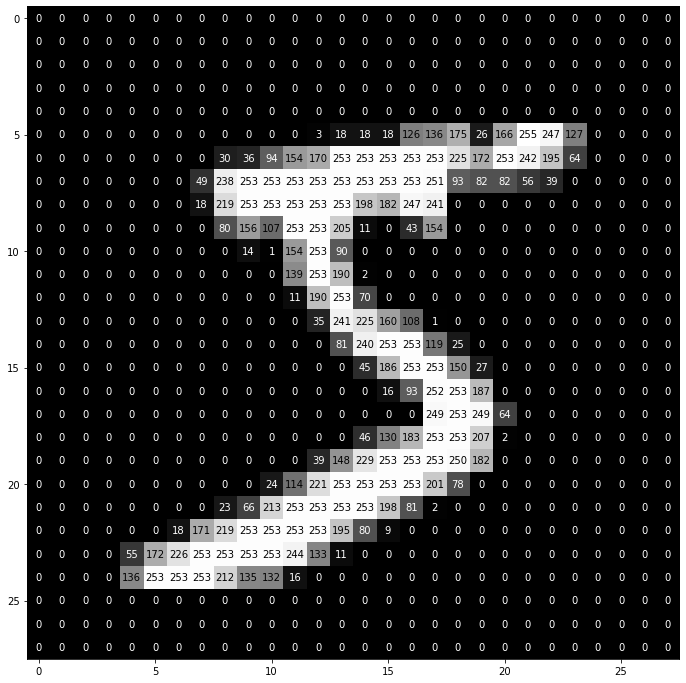

In [5]:
def visualize_input(img, ax):
    ax.imshow(img, cmap='gray')
    width, height = img.shape
    thresh = img.max()/2.5
    for x in range(width):
        for y in range(height):
            ax.annotate(str(round(img[x][y],2)), xy=(y,x),
                        horizontalalignment='center',
                        verticalalignment='center',
                        color='white' if img[x][y]<thresh else 'black')

fig = plt.figure(figsize = (12,12)) 
ax = fig.add_subplot(111)
visualize_input(X_train[0].reshape(28,28), ax)

In [6]:
X_train = X_train.astype('float32')/255
X_val = X_val.astype('float32')/255
X_test = X_test.astype('float32')/255 


In [7]:
print('Integer-valued labels:')
print(y_train[:10])

Integer-valued labels:
[5 0 4 1 9 2 1 3 1 4]


## 4. Label Encoding

One hot encoding as there are cetogorical variables

In [8]:
# one-hot encode the labels
y_train = np_utils.to_categorical(y_train, 10)
y_val = np_utils.to_categorical(y_val, 10)

# print first ten (one-hot) training labels
print('One-hot Encoding:')
print(y_train[:10])

One-hot Encoding:
[[0. 0. 0. 0. 0. 1. 0. 0. 0. 0.]
 [1. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 1. 0. 0. 0. 0. 0.]
 [0. 1. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 1.]
 [0. 0. 1. 0. 0. 0. 0. 0. 0. 0.]
 [0. 1. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 1. 0. 0. 0. 0. 0. 0.]
 [0. 1. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 1. 0. 0. 0. 0. 0.]]


## 5. Training Convolutional Model

In [9]:
from keras.models import Sequential
from keras.layers import Dense, Dropout, Flatten, Conv2D, MaxPooling2D

# define the model
model = Sequential()
model.add(Conv2D(filters=64, kernel_size=3, padding='same', activation='relu', input_shape=(28,28,1)))
model.add(Conv2D(filters=64, kernel_size=3, padding='same', activation='relu'))
model.add(Conv2D(filters=128, kernel_size=3, padding='same', activation='relu'))
model.add(MaxPooling2D(pool_size=2))
model.add(Conv2D(filters=128, kernel_size=3, padding='same', activation='relu'))
model.add(Conv2D(filters=192, kernel_size=3, padding='same', activation='relu'))
model.add(MaxPooling2D(pool_size=2))
model.add(Conv2D(filters=192, kernel_size=5, padding='same', activation='relu'))
model.add(MaxPooling2D(pool_size=2, padding='same'))
model.add(Flatten())
model.add(Dense(256, activation='relu'))
model.add(Dense(10, activation='softmax'))
# summarize the model
model.summary()

Model: "sequential"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
conv2d (Conv2D)              (None, 28, 28, 64)        640       
_________________________________________________________________
conv2d_1 (Conv2D)            (None, 28, 28, 64)        36928     
_________________________________________________________________
conv2d_2 (Conv2D)            (None, 28, 28, 128)       73856     
_________________________________________________________________
max_pooling2d (MaxPooling2D) (None, 14, 14, 128)       0         
_________________________________________________________________
conv2d_3 (Conv2D)            (None, 14, 14, 128)       147584    
_________________________________________________________________
conv2d_4 (Conv2D)            (None, 14, 14, 192)       221376    
_________________________________________________________________
max_pooling2d_1 (MaxPooling2 (None, 7, 7, 192)         0

2022-12-23 13:19:28.228256: I tensorflow/core/common_runtime/process_util.cc:146] Creating new thread pool with default inter op setting: 2. Tune using inter_op_parallelism_threads for best performance.


## 6. Compile the Model

In [10]:
# compile the model
model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

In [11]:
from keras.callbacks import ModelCheckpoint   
from keras.callbacks import ReduceLROnPlateau

# train the model
reduce_lr = ReduceLROnPlateau(monitor='loss', factor=0.3, verbose=1, patience=2, min_lr=0.00000001)

history = model.fit(X_train, y_train, batch_size= 100, epochs=15,
          validation_data=(X_val, y_val), callbacks=[reduce_lr], verbose=1, shuffle=True)

2022-12-23 13:19:28.734748: I tensorflow/compiler/mlir/mlir_graph_optimization_pass.cc:185] None of the MLIR Optimization Passes are enabled (registered 2)


Epoch 1/15
700/700 [==============================] - 871s 1s/step - loss: 0.1244 - accuracy: 0.9611 - val_loss: 0.0452 - val_accuracy: 0.9865
Epoch 2/15
700/700 [==============================] - 878s 1s/step - loss: 0.0320 - accuracy: 0.9902 - val_loss: 0.0254 - val_accuracy: 0.9923
Epoch 3/15
700/700 [==============================] - 874s 1s/step - loss: 0.0241 - accuracy: 0.9926 - val_loss: 0.0128 - val_accuracy: 0.9960
Epoch 4/15
700/700 [==============================] - 873s 1s/step - loss: 0.0185 - accuracy: 0.9945 - val_loss: 0.0228 - val_accuracy: 0.9926
Epoch 5/15
700/700 [==============================] - 860s 1s/step - loss: 0.0164 - accuracy: 0.9951 - val_loss: 0.0078 - val_accuracy: 0.9972
Epoch 6/15
700/700 [==============================] - 860s 1s/step - loss: 0.0131 - accuracy: 0.9963 - val_loss: 0.0165 - val_accuracy: 0.9955
Epoch 7/15
700/700 [==============================] - 868s 1s/step - loss: 0.0112 - accuracy: 0.9966 - val_loss: 0.0111 - val_accuracy: 0.9963

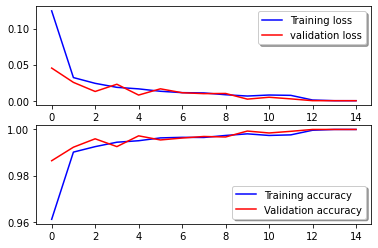

In [12]:
# Can judge whether it is under-fitting or over-fitting
fig, ax = plt.subplots(2,1)
ax[0].plot(history.history['loss'], color='b', label="Training loss")
ax[0].plot(history.history['val_loss'], color='r', label="validation loss",axes =ax[0])
legend = ax[0].legend(loc='best', shadow=True)

ax[1].plot(history.history['accuracy'], color='b', label="Training accuracy")
ax[1].plot(history.history['val_accuracy'], color='r',label="Validation accuracy")
legend = ax[1].legend(loc='best', shadow=True)

## 7. Predicting on test Data

In [13]:
testY = model.predict(X_test, verbose=2)

875/875 - 95s


In [14]:
sub = pd.read_csv('/kaggle/input/digit-recognizer/sample_submission.csv')
sub['Label'] = testY
sub.to_csv('submission.csv',index=False)

# UPVOTE this kernel if you found it useful, feel free in comments.